# Graphics Card Market Analysis - Web Scraping Project

## Project Overview
In this project, you will create a web scraper to collect and analyze graphics card data from Newegg.com's GPU section. You'll use Python, BeautifulSoup, and other relevant libraries to extract key information about graphics cards currently available in the market.

## Learning Objectives
- Implement web scraping techniques using Python and BeautifulSoup
- Handle pagination in web scraping
- Process and structure collected data
- Practice working with real-world data
- Learn to respect website scraping policies and implement delays

## Part 1: Web scrapping
## Required Data to Extract
For each graphics card listing, you must collect:
1. Product Image URL
2. Product Title (e.g., "MSI Ventus GeForce RTX 3060 12GB")
3. Product Details:
   - Manufacturer
   - Model Number
   - Rating (number of stars)
5. Pricing Information:
   - Current Price
   - Original Price (if available)
   - Shipping Information

![Screenshot](image.png)

## Project Requirements

### Technical Requirements
1. Use Python 3.x
2. Required libraries:
   - requests
   - beautifulsoup4
   - pandas
   - time (for implementing delays)

### Functional Requirements
1. Implement proper error handling
2. Include appropriate delays between requests (minimum 2 seconds)
3. Save the scraped data to a CSV file with appropriate column headers
4. Document your code with comments
5. Create a summary of the collected data (e.g., average price, price range)

## Part 2: Data Analysis
### Required Analysis

1. Price Analysis
   - Calculate average price by brand
   - Identify price ranges and market segments
   - Analyze price-to-memory ratio
   - Compare prices across different GPU series (RTX 3000 vs 4000)
   - Create price distribution visualizations

2. Brand Analysis
   - Market share by brand
   - Average ratings by brand
   - Price comparison across brands
   - Create brand comparison visualizations

3. Memory Configuration Analysis
   - Distribution of memory sizes
   - Price correlation with memory size
   - Popular memory configurations by brand

4. Market Segmentation
   - Entry-level vs Mid-range vs High-end segments
   - Price brackets and their features





## Deliverables
1. Python script containing the web scraper
2. CSV file with the collected data
3. README file explaining:
   - Project Description
   - Features
5. Short report analyzing the collected data

## Important Notes
- Always check and respect the website's robots.txt file
- Implement appropriate delays between requests to avoid overwhelming the server
- Handle your requests responsibly and ethically
- Be prepared to handle cases where data might be missing or in an unexpected format

In [11]:
import selenium
from selenium import webdriver

In [12]:
import selenium
from selenium import webdriver
# Import chrome webdriver to access chrome options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait, Select
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import time

In [13]:
from tqdm import tqdm

In [14]:
import requests

url2 = "https://www.newegg.com/GPUs-Video-Graphics-Cards/SubCategory/ID-48"
requests.get(url2)

<Response [200]>

In [15]:
url = "https://www.newegg.com/Desktop-Graphics-Cards/SubCategory/ID-48"

service = Service(ChromeDriverManager().install())
options = Options()
options.add_argument('--headless=new')
driver = webdriver.Chrome(options=options)
driver.get(url)
time.sleep(5)

gpus = []
page = 1
PAGES_TO_SCRAPE = 20

while page <= PAGES_TO_SCRAPE:
    attempt = 0
    page_products = []

    while attempt < 3:
        driver.get(url + '/Page-' + str(page))
        time.sleep(2)
        products = driver.find_elements(By.CLASS_NAME, 'item-cell')

        if len(products) >= 36:
            page_products = products
            break
        else:
            attempt += 1
            print(f"Page {page} returned {len(products)} products, retrying...")
            time.sleep(3)

    if not page_products:
        print(f"Page {page} failed after 3 attempts, skipping.")
        page += 1
        continue

    for product in tqdm(products, f'Page {page} in progress...'):
        img = product.find_elements(By.CLASS_NAME, 'item-img')
        if img:
            img = img[0].find_element(By.TAG_NAME, 'img').get_attribute('src')
        else:
            img = None

        rating = product.find_elements(By.CLASS_NAME, 'item-rating')
        if rating:
            rating = rating[0].get_attribute('title').split('+ ', 1)[-1]
        else:
            rating = None

        reviews = product.find_elements(By.CLASS_NAME, 'item-rating-num')
        if reviews:
            reviews = reviews[0].text
        else:
            reviews = None

        brand = product.find_elements(By.CLASS_NAME, 'item-brand')
        if brand:
            brand = brand[0].find_element(By.TAG_NAME, 'img').get_attribute('title')
        else:
            brand = None

        title = product.find_elements(By.CLASS_NAME, 'item-title')[0].text
        if not title:
            continue

        model = product.find_elements(By.CLASS_NAME, 'item-features')
        if model:
            model_raw = model[0].text
            model_text = model_raw.split(': ', 1)[-1]
        else:
            model_text = None

        price = product.find_elements(By.CLASS_NAME, 'price-current')
        if price:
            price = price[0].text.split(' ', 1)[0]
        else:
            price = None

        shipping_price = product.find_elements(By.CLASS_NAME, 'price-ship')
        if shipping_price:
            shipping_price = shipping_price[0].text
        else:
            shipping_price = None

        original_price = product.find_elements(By.CLASS_NAME, 'price-was')
        if original_price:
            original_price = original_price[0].text
        else:
            original_price = None

        gpu = {
            'img': img,
            'rating': rating,
            'reviews': reviews,
            'brand': brand,
            'title': title,
            'model': model_text,
            'price': price,
            'shipping_price': shipping_price,
            'original_price': original_price
        }
        gpus.append(gpu)

    page+=1

time.sleep(3)
driver.quit()

df = pd.DataFrame(gpus)
df.to_csv('newegg.csv', index=False)

Page 1 in progress...:   0%|                                                                    | 0/36 [00:00<?, ?it/s]

Page 1 in progress...:   3%|█▋                                                          | 1/36 [00:01<00:42,  1.22s/it]

Page 1 in progress...:   6%|███▎                                                        | 2/36 [00:01<00:24,  1.41it/s]

Page 1 in progress...:   8%|█████                                                       | 3/36 [00:01<00:17,  1.86it/s]

Page 1 in progress...:  11%|██████▋                                                     | 4/36 [00:02<00:15,  2.11it/s]

...

Page 20 in progress...:  92%|█████████████████████████████████████████████████████▏    | 33/36 [00:09<00:00,  3.49it/s]

Page 20 in progress...:  94%|██████████████████████████████████████████████████████▊   | 34/36 [00:09<00:00,  3.53it/s]

Page 20 in progress...:  97%|████████████████████████████████████████████████████████▍ | 35/36 [00:09<00:00,  3.58it/s]

Page 20 in progress...: 100%|██████████████████████████████████████████████████████████| 36/36 [00:09<00:00,  3.76it/s]

Page 20 in progress...: 100%|██████████████████████████████████████████████████████████| 36/36 [00:09<00:00,  3.64it/s]

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("newegg.csv")
print(df.shape)
df.head()

(720, 9)


,img,rating,reviews,brand,title,model,price,shipping_price,original_price
0,https://c1.neweggimages.com/productimage/nb300...,4.7,(125),Sapphire Tech,SAPPHIRE PULSE Radeon RX 9060 XT 16GB GDDR6 PC...,11350-03-20G,$499.99,Free Shipping,NaN
1,https://c1.neweggimages.com/productimage/nb300...,4.7,(111),ASRock,ASRock Challenger Radeon RX 9060 XT 16GB GDDR6...,RX9060XT CL 16GO,$469.99,Free Shipping,$498.49
2,https://c1.neweggimages.com/productimage/nb300...,4.8,(241),GIGABYTE,GIGABYTE Gaming GeForce RTX 5070 Ti 16GB GDDR7...,GV-N507TGAMING OC-16GD,"$1,249.99",Free Shipping,NaN
3,https://c1.neweggimages.com/productimage/nb300...,4.6,(139),ASRock,ASRock Challenger Radeon RX 9070 XT 16GB GDDR6...,RX9070XT CL 16G,$808.99,Free Shipping,NaN
4,https://c1.neweggimages.com/productimage/nb300...,4.5,(74),ASRock,ASRock Challenger Radeon RX 9070 16GB GDDR6 PC...,RX9070 CL 16G,$649.99,Free Shipping,$650.00


In [19]:

df["brand"] = df["brand"].fillna(df["title"].str.split().str[0])


df["price"] = pd.to_numeric(df["price"].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")
df["original_price"] = pd.to_numeric(df["original_price"].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")

df["rating"] = pd.to_numeric(df["rating"].astype(str).str.extract(r"([0-9.]+)")[0], errors="coerce")
df["reviews"] = pd.to_numeric(df["reviews"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")


df["memory_gb"] = pd.to_numeric(df["title"].str.extract(r"(\d+)\s*GB")[0], errors="coerce")

t = df["title"].str.upper()
df["series"] = np.select(
    [t.str.contains("ADA"), t.str.contains(r"\bA10\b"),
     t.str.contains(r"RTX\s*50"), t.str.contains(r"RTX\s*40"), t.str.contains(r"RTX\s*30"),
     t.str.contains(r"GTX\s*16"), t.str.contains(r"GTX\s*10"),
     t.str.contains(r"RX\s*9\d{3}"), t.str.contains(r"RX\s*7\d{3}"), t.str.contains(r"RX\s*6\d{3}")],
    ["RTX Ada (Pro)", "NVIDIA A-series (Pro)", "RTX 5000", "RTX 4000", "RTX 3000",
     "GTX 1600", "GTX 1000", "RX 9000", "RX 7000", "RX 6000"],
    default="Other")

df = df.dropna(subset=["price"]).reset_index(drop=True)
df["price_per_gb"] = (df["price"] / df["memory_gb"]).round(2)

print("Clean rows:", len(df))
df[["brand", "series", "memory_gb", "price", "rating"]].head()

Clean rows: 717


,brand,series,memory_gb,price,rating
0,Sapphire Tech,RX 9000,16.0,499.99,4.7
1,ASRock,RX 9000,16.0,469.99,4.7
2,GIGABYTE,RTX 5000,16.0,1249.99,4.8
3,ASRock,RX 9000,16.0,808.99,4.6
4,ASRock,RX 9000,16.0,649.99,4.5


brand
MAXSUN           1457.50
NVIDIA           1336.07
ASUS             1289.69
PNY              1075.94
ZOTAC            1013.36
GIGABYTE          954.12
MSI               885.45
Sapphire Tech     817.39
HP                809.00
PowerColor        677.26
Yeston            669.06
Intel             590.00
XFX               560.76
EVGA              477.52
ASRock            447.74
REFURBISHED       376.66
GUNNIR            353.00
ONIX              309.99
AMD               304.32
Peladn            281.33
Lenovo            268.07
SongryVGA         176.35
SRhonyra          162.22
GPVHOSO           149.99
ZER               143.32
USED              139.99
Srhonyra          125.59
PELADN            113.50
Name: price, dtype: float64


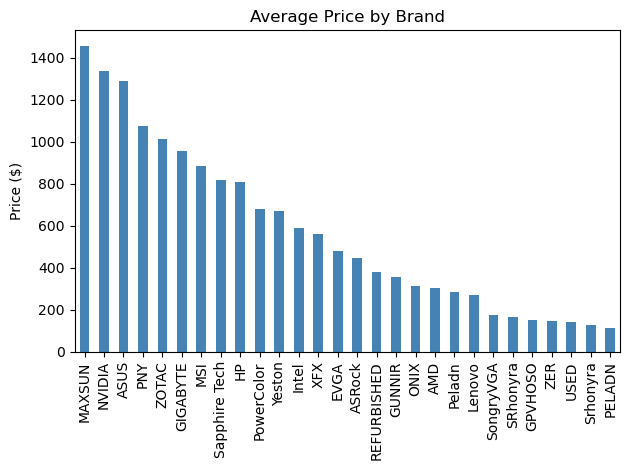

In [20]:
avg_price_brand = df.groupby("brand")["price"].mean().sort_values(ascending=False)
print(avg_price_brand.round(2))

avg_price_brand.plot(kind="bar", color="steelblue")
plt.title("Average Price by Brand"); plt.ylabel("Price ($)"); plt.xlabel("")
plt.tight_layout(); plt.show()

In [21]:
print(df.groupby("series")["price"].agg(["count", "mean", "min", "max"]).round(2))
print(df.groupby("series")["price_per_gb"].mean().sort_values().round(2))

               count     mean     min      max
series                                        
GTX 1000          38   249.43   97.95   399.00
GTX 1600          21   274.84  179.99   420.00
Other            157   353.32   18.74  2849.00
RTX 3000          89   741.33  219.99  2199.00
RTX 4000          84  1395.91  339.99  3895.00
RTX 5000         177  1520.74  299.99  6999.00
RTX Ada (Pro)      9  3006.11  829.00  8199.00
RX 6000           40   430.92  159.99   789.00
RX 7000           30   995.05  319.99  1659.99
RX 9000           72   743.40  359.99  1799.99
series
GTX 1000          46.41
RX 6000           49.75
RX 9000           50.31
RX 7000           52.11
Other             54.91
RTX 3000          59.27
GTX 1600          60.96
RTX 4000          90.22
RTX 5000          90.42
RTX Ada (Pro)    108.78
Name: price_per_gb, dtype: float64


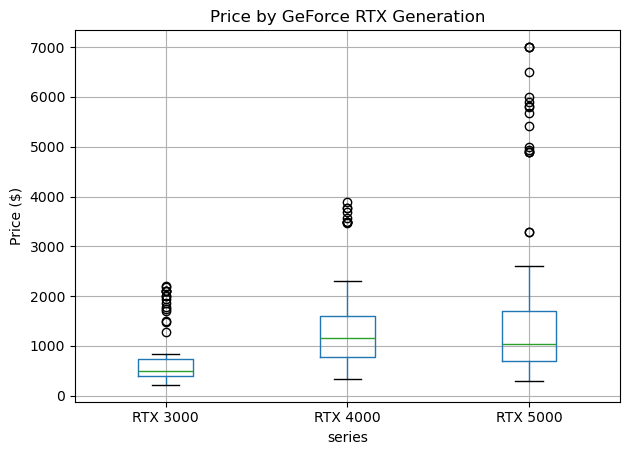

In [22]:
rtx = df[df["series"].isin(["RTX 3000", "RTX 4000", "RTX 5000"])]
rtx.boxplot(column="price", by="series")
plt.title("Price by GeForce RTX Generation"); plt.suptitle("")
plt.ylabel("Price ($)"); plt.tight_layout(); plt.show()

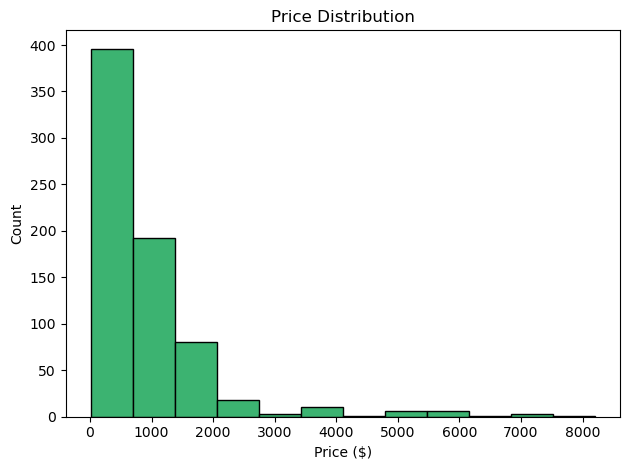

In [23]:
plt.hist(df["price"], bins=12, color="mediumseagreen", edgecolor="black")
plt.title("Price Distribution"); plt.xlabel("Price ($)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

In [32]:
market_share = df["brand"].value_counts()
print((market_share / len(df) * 100).round(1))



brand
ASUS             20.4
GIGABYTE         18.4
MSI              15.6
NVIDIA            6.6
Sapphire Tech     4.7
ZOTAC             4.6
ASRock            3.9
XFX               3.6
PNY               3.2
EVGA              2.9
PowerColor        2.9
SongryVGA         2.4
Yeston            2.2
SRhonyra          2.2
AMD               0.8
REFURBISHED       0.8
MAXSUN            0.8
Peladn            0.8
GUNNIR            0.7
Lenovo            0.6
ZER               0.4
PELADN            0.3
HP                0.3
GPVHOSO           0.1
Srhonyra          0.1
ONIX              0.1
Intel             0.1
USED              0.1
Name: count, dtype: float64


brand
AMD              5.00
ZER              5.00
Lenovo           5.00
MAXSUN           5.00
USED             4.80
NVIDIA           4.77
XFX              4.65
ASUS             4.65
Yeston           4.59
MSI              4.57
Peladn           4.56
Sapphire Tech    4.56
GIGABYTE         4.55
PNY              4.52
ONIX             4.50
ZOTAC            4.49
EVGA             4.49
REFURBISHED      4.38
ASRock           4.35
PowerColor       4.28
PELADN           4.00
SRhonyra         3.88
SongryVGA        3.60
GPVHOSO           NaN
GUNNIR            NaN
HP                NaN
Intel             NaN
Srhonyra          NaN
Name: rating, dtype: float64


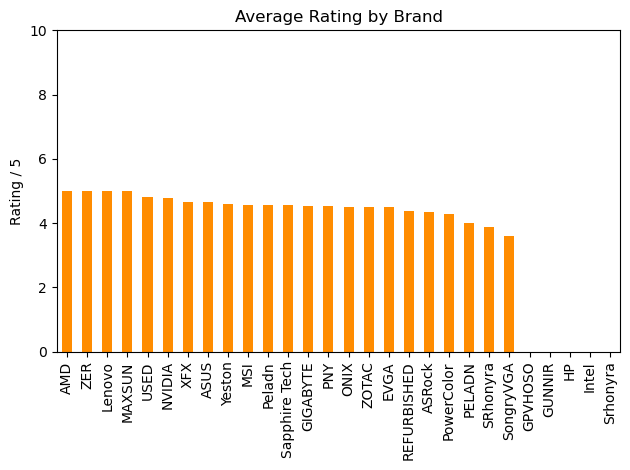

In [25]:
avg_rating_brand = df.groupby("brand")["rating"].mean().sort_values(ascending=False)
print(avg_rating_brand.round(2))

avg_rating_brand.plot(kind="bar", color="darkorange")
plt.title("Average Rating by Brand"); plt.ylabel("Rating / 5"); plt.ylim(0, 10)
plt.xlabel(""); plt.tight_layout(); plt.show()

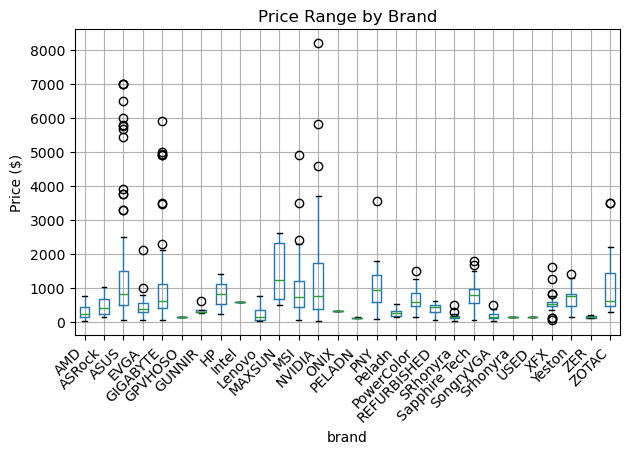

In [26]:
df.boxplot(column="price", by="brand")
plt.title("Price Range by Brand"); plt.suptitle("")
plt.ylabel("Price ($)"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

memory_gb
1.0       11
2.0       34
3.0        9
4.0       47
6.0       29
8.0      149
10.0      12
11.0       9
12.0     107
16.0     200
20.0       7
24.0      39
32.0      17
48.0       1
448.0      2
640.0      1
Name: count, dtype: int64


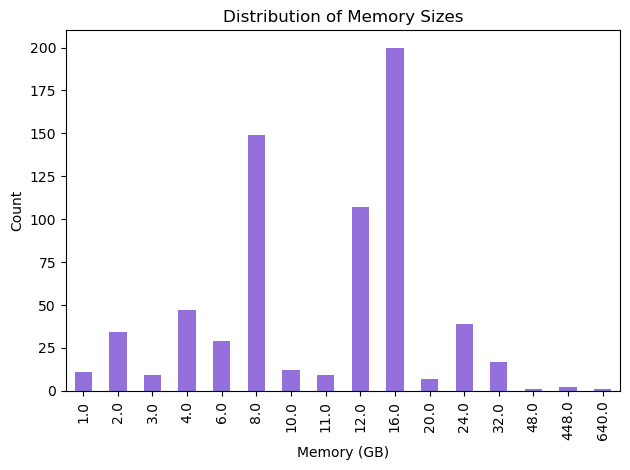

In [27]:
mem_counts = df["memory_gb"].value_counts().sort_index()
print(mem_counts)

mem_counts.plot(kind="bar", color="mediumpurple")
plt.title("Distribution of Memory Sizes"); plt.xlabel("Memory (GB)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()

correlation: 0.18


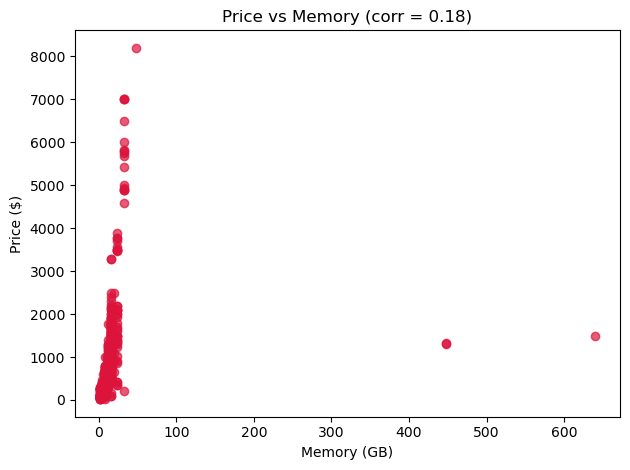

In [28]:
corr = df["memory_gb"].corr(df["price"])
print("correlation:", round(corr, 2))

plt.scatter(df["memory_gb"], df["price"], alpha=0.7, color="crimson")
plt.title("Price vs Memory (corr = %.2f)" % corr)
plt.xlabel("Memory (GB)"); plt.ylabel("Price ($)")
plt.tight_layout(); plt.show()

In [29]:
df.groupby("brand")["memory_gb"].agg(lambda x: x.mode()[0])

brand
AMD              12.0
ASRock           16.0
ASUS             16.0
EVGA              8.0
GIGABYTE          8.0
GPVHOSO           6.0
GUNNIR            8.0
HP                2.0
Intel            12.0
Lenovo            1.0
MAXSUN            8.0
MSI              16.0
NVIDIA           16.0
ONIX             12.0
PELADN            4.0
PNY              16.0
Peladn            8.0
PowerColor       16.0
REFURBISHED      12.0
SRhonyra          2.0
Sapphire Tech    16.0
SongryVGA         4.0
Srhonyra          3.0
USED              3.0
XFX              16.0
Yeston           16.0
ZER               4.0
ZOTAC             8.0
Name: memory_gb, dtype: float64

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5616\865701589.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_table = df.groupby("segment").agg(


                       count  avg_price  avg_memory  avg_rating
segment                                                        
Entry-level (<$500)      298     289.85        7.23        4.43
Mid-range ($500-1200)    256     769.42       12.64        4.60
High-end (>$1200)        163    2254.29       29.18        4.66


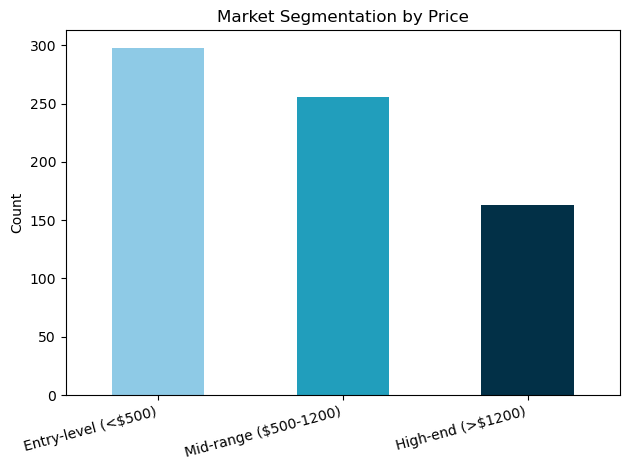

In [30]:
df["segment"] = pd.cut(df["price"], bins=[0, 500, 1200, float("inf")],
                       labels=["Entry-level (<$500)", "Mid-range ($500-1200)", "High-end (>$1200)"])

seg_table = df.groupby("segment").agg(
    count=("price", "size"), avg_price=("price", "mean"),
    avg_memory=("memory_gb", "mean"), avg_rating=("rating", "mean")).round(2)
print(seg_table)

seg_table["count"].plot(kind="bar", color=["#8ecae6", "#219ebc", "#023047"])
plt.title("Market Segmentation by Price"); plt.ylabel("Count"); plt.xlabel("")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

In [31]:
df.to_csv("newegg_gpus_clean.csv", index=False)
print("Saved newegg_gpus_clean.csv")

Saved newegg_gpus_clean.csv
